# Corr_3PCF: Standard and Multipole Three-Point Statistics

This notebook develops the 3PCF workflow in four stages:

1. run the standard 3PCF through the high-level task interface
2. reconstruct the same estimator from the lower-level field operations
3. diagnose the effects of random handling, center choice, and angular sampling
4. inspect the multipole representation and its consistency with the angular 3PCF

## Core idea

PyHermes evaluates the field values at the three vertices of each triangle, averages their product over many rotations and centers, and then forms the reduced statistic `Q = zeta / zeta_H`. The choice of center sampling leads to the two main estimator styles used below: particle centers and box-random centers.


In [1]:
from pyhermes.theory.corr3pcf import Corr_3PCF
from pyhermes.param.parambase import read_param
from pyhermes.utils.sampling import random_box_positions
from pyhermes.io import WindowFunc, SFCField, Corr3PCFData, Corr3PCFMultipoleData
import matplotlib.pyplot as plt
import numpy as np

from pathlib import Path
import os
os.chdir(Path.cwd().resolve().parent)
print(f"Working directory: {Path.cwd()}")

figs_dir = Path("figs")
figs_dir.mkdir(exist_ok=True)


Working directory: /Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples


## 1. Standard 3PCF workflows

The standard task is controlled by the triangle side lengths, the angular sampling, the number of random rotations, the center strategy, and the smoothing windows applied to its vertex fields.


### Minimal YAML Shapes

For the standard reduced 3PCF, the minimal shape fixes the field inputs, triangle side lengths, angular sampling, center strategy, and products:

```yaml
Corr_3PCF:
   sfc_field: "./output/quijote8000_snap004_sfc.pkl"
   random: "uniform"
   window:
      type: "sphere"
      len_args:
         R: 5
   r12: 20.0
   r13: 40.0
   theta:
      n_theta: 20
   n_rot: 20
   center: "particle"
   products: ["ddd", "Q"]
   threads: 2
   fout_path: "./output/quijote8000_snap004_3pcf_pcenter_nrot20.pkl"
```

For random box centers, switch the center strategy and provide the number of box centers:

```yaml
Corr_3PCF:
   center: "box_random"
   n_box_centers: 1000000
```


### Command-line entry point

The first two runs use the standard driver script with two different center choices: particle centers and random box centers.


In [2]:
! mpirun -np 4 python ./scripts/run_3pcf.py ./configs/param_3pcf_pcenter_nrot20.yaml

17:19:25 - INFO - pyhermes.param.parambase:ParamBase - Reading configure file: './configs/param_3pcf_pcenter_nrot20.yaml'
17:19:25 - INFO - pyhermes.param.parambase:ParamBase - Input parameter file format is YAML
17:19:25 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...
17:19:25 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_3PCF.sfc_field' from 'empty' to './output/quijote8000_snap004_sfc.pkl'
17:19:25 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_3PCF.random' from 'None' to 'uniform'
17:19:25 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_3PCF.window.type' from 'empty' to 'sphere'
17:19:25 - WARNING - pyhermes.param.parambase:ParamBase - Adding non-default key: 'Corr_3PCF.window.len_args.R'
17:19:25 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_3PCF.n_rot' from '100' to '20'
17:19:25 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_3PCF.center' from 'box_random' to 'particle'
1

In [3]:
! mpirun -np 4 python ./scripts/run_3pcf.py ./configs/param_3pcf_rcenter_nrot20.yaml

17:20:29 - INFO - pyhermes.param.parambase:ParamBase - Reading configure file: './configs/param_3pcf_rcenter_nrot20.yaml'
17:20:29 - INFO - pyhermes.param.parambase:ParamBase - Input parameter file format is YAML
17:20:29 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...
17:20:29 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_3PCF.sfc_field' from 'empty' to './output/quijote8000_snap004_sfc.pkl'
17:20:29 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_3PCF.random' from 'None' to 'uniform'
17:20:29 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_3PCF.window2.type' from 'empty' to 'sphere'
17:20:29 - WARNING - pyhermes.param.parambase:ParamBase - Adding non-default key: 'Corr_3PCF.window2.len_args.R'
17:20:29 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_3PCF.window3.type' from 'empty' to 'sphere'
17:20:29 - WARNING - pyhermes.param.parambase:ParamBase - Adding non-default key: 'Corr_3PCF.window3

### Compare particle-center and box-random-center saved outputs

The next cell reloads both results and compares their reduced 3PCF curves directly. This is the fastest way to see how the estimator choice changes the measured `Q(theta)`.


17:23:00 - INFO - pyhermes.io.base:Corr3PCFData - Reading 3PCF data from ---> ./output/quijote8000_snap004_3pcf_pcenter_nrot20.pkl <---
17:23:00 - INFO - pyhermes.io.base:Corr3PCFData - theta: Num = 20, Min = 0, Max = 3.142
17:23:00 - INFO - pyhermes.io.base:Corr3PCFData - mu: Num = 20, Min = -1, Max = 1
17:23:00 - INFO - pyhermes.io.base:Corr3PCFData - Products loaded: ['ddd', 'rrr', 'd_delta_dd', 'r_delta_dd', 'delta_ddd', 'xi12', 'xi13', 'xi23', 'zeta', 'zeta_H', 'Q']
17:23:00 - INFO - pyhermes.io.base:Corr3PCFData - Reading 3PCF data from ---> ./output/quijote8000_snap004_3pcf_rcenter_nrot20.pkl <---
17:23:00 - INFO - pyhermes.io.base:Corr3PCFData - theta: Num = 20, Min = 0, Max = 3.142
17:23:00 - INFO - pyhermes.io.base:Corr3PCFData - mu: Num = 20, Min = -1, Max = 1
17:23:00 - INFO - pyhermes.io.base:Corr3PCFData - Products loaded: ['rrr', 'delta_ddd', 'xi12', 'xi13', 'xi23', 'zeta', 'zeta_H', 'Q']


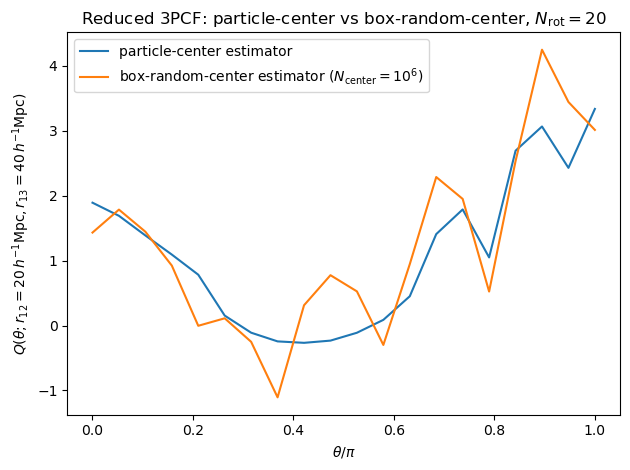

In [4]:
corr3pcf_pcent = Corr3PCFData(data_path='./output/quijote8000_snap004_3pcf_pcenter_nrot20.pkl')
corr3pcf_rcent = Corr3PCFData(data_path='./output/quijote8000_snap004_3pcf_rcenter_nrot20.pkl')
plt.plot(corr3pcf_pcent.theta/np.pi, corr3pcf_pcent.Q, label='particle-center estimator')
plt.plot(corr3pcf_rcent.theta/np.pi, corr3pcf_rcent.Q, label=r'box-random-center estimator ($N_{\rm center}=10^6$)')
plt.xlabel(r"$\theta/\pi$")
plt.ylabel(r"$Q(\theta; r_{12}=20\,h^{-1}\mathrm{Mpc}, r_{13}=40\,h^{-1}\mathrm{Mpc})$")
plt.legend()
plt.title(r'Reduced 3PCF: particle-center vs box-random-center, $N_{\rm rot}=20$')
plt.tight_layout()
plt.show()


### Config-driven Python API

This version keeps the YAML config in charge but returns the result directly to the notebook, which is useful for quick parameter scans.


In [5]:
corr3pcf_params = read_param('./configs/param_3pcf_pcenter_nrot20.yaml')
task = Corr_3PCF(param_task=corr3pcf_params)
task.threads = 8
task.products = 'Q'
corr3pcf = task.run(save_result=False)

17:23:01 - INFO - pyhermes.param.parambase:ParamBase - Reading configure file: './configs/param_3pcf_pcenter_nrot20.yaml'
17:23:01 - INFO - pyhermes.param.parambase:ParamBase - Input parameter file format is YAML
17:23:01 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...
17:23:01 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_3PCF.sfc_field' from 'empty' to './output/quijote8000_snap004_sfc.pkl'
17:23:01 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_3PCF.random' from 'None' to 'uniform'
17:23:01 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_3PCF.window.type' from 'empty' to 'sphere'
17:23:01 - WARNING - pyhermes.param.parambase:ParamBase - Adding non-default key: 'Corr_3PCF.window.len_args.R'
17:23:01 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_3PCF.n_rot' from '100' to '20'
17:23:01 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_3PCF.center' from 'box_random' to 'particle'
1

### Task object overrides

These cells show a mixed-object workflow in which data fields, random fields, and windows can be supplied either as loaded objects or as paths. This is often the most practical level for custom experiments.


In [6]:
D = SFCField(data_path='./output/quijote8000_snap004_sfc.pkl', threads=8)
random = SFCField(data_path='./output/random_sfc.pkl', threads=8)
win_params_sph5 = {"type": "sphere", "len_args": {"R": 5}}
filter_sph5 = WindowFunc(win_params_sph5, D.sfc_info, threads=8)

17:23:45 - INFO - pyhermes.io.base:SFCField - Reading SFCField data from ---> ./output/quijote8000_snap004_sfc.pkl <---
17:23:45 - INFO - pyhermes.io.base:SFCField - epsilon: Shape(256, 256, 256), Min = -3.215e-06, Max = 1.343e-05, Mean = 5.96e-08, Sum = 1
17:23:45 - INFO - pyhermes.io.base:SFCField - Reading SFCField data from ---> ./output/random_sfc.pkl <---
17:23:46 - INFO - pyhermes.io.base:SFCField - epsilon: Shape(256, 256, 256), Min = -2.192e-07, Max = 9.48e-07, Mean = 5.96e-08, Sum = 1


In [7]:
task = Corr_3PCF()
task.sfc_field1 = D
task.sfc_field2 = "./output/quijote8000_snap004_sfc.pkl"
task.sfc_field3 = "./output/quijote8000_snap004_sfc.pkl"
task.random1 = "uniform"
task.random2 = "./output/random_sfc.pkl"
task.random3 = random
task.window2 = win_params_sph5
task.window3 = filter_sph5
task.r12 = 20.0
task.r23 = 40.0
task.n_theta = 20
task.n_rot = 20
task.center = "particle"
# task.particle_pos1 = D.get_particle_data()['pos']
# task.random_pos1 = random_box_positions(count=1000000, box_size=1000, seed=42)
task.products = "Q"
task.threads = 8
corr3pcf1 = task.run(save_result=False)

17:23:46 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...

17:23:46 - INFO - pyhermes.pipeline.pipeline:Corr_3PCF - Corr_3PCF runtime configuration: running on 1 MPI ranks with 8 threads per rank
17:23:46 - INFO - pyhermes.pipeline.pipeline:Corr_3PCF - Field weight normalization rule | task weight_normalization=catalog | catalog fields are converted to the task rule; derived fields are used as-is except for task='unit'.
17:23:46 - INFO - pyhermes.pipeline.pipeline:Corr_3PCF - Preparing Corr_3PCF input fields ...
17:23:46 - INFO - pyhermes.pipeline.pipeline:Corr_3PCF - center=particle, r12=20.0, r13=40.0, n_rot=20, base_seed=42, threads=8
17:23:46 - INFO - pyhermes.pipeline.pipeline:Corr_3PCF - angle_param=theta, theta_min=0.0, theta_max=3.141592653589793, n_theta=20
17:23:46 - INFO - pyhermes.pipeline.pipeline:Corr_3PCF - requested_products=Q, expanded_products=['Q', 'zeta', 'zeta_H', 'delta_ddd', 'rrr', 'xi12', 'xi13', 'xi23', 'd_delta_dd', '

### Reconstruct `Q` from stored components

The saved 3PCF object contains the intermediate pieces needed to rebuild the reduced statistic. The next cell makes that relationship explicit.


17:24:20 - INFO - pyhermes.io.base:Corr3PCFData - Reading 3PCF data from ---> ./output/quijote8000_snap004_3pcf_pcenter_nrot20.pkl <---
17:24:20 - INFO - pyhermes.io.base:Corr3PCFData - theta: Num = 20, Min = 0, Max = 3.142
17:24:20 - INFO - pyhermes.io.base:Corr3PCFData - mu: Num = 20, Min = -1, Max = 1
17:24:20 - INFO - pyhermes.io.base:Corr3PCFData - Products loaded: ['ddd', 'rrr', 'd_delta_dd', 'r_delta_dd', 'delta_ddd', 'xi12', 'xi13', 'xi23', 'zeta', 'zeta_H', 'Q']


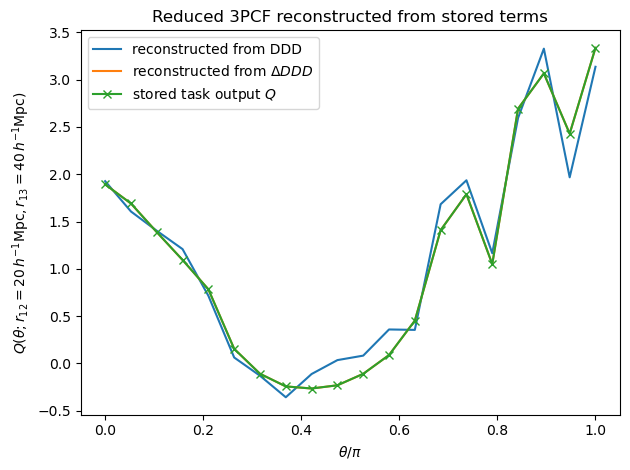

In [8]:
corr3pcf = Corr3PCFData(data_path="./output/quijote8000_snap004_3pcf_pcenter_nrot20.pkl")
Q1 = (corr3pcf.ddd / corr3pcf.rrr - 1 - corr3pcf.xi12 - corr3pcf.xi23 - corr3pcf.xi13)/corr3pcf.zeta_H
Q2 = corr3pcf.delta_ddd / corr3pcf.rrr / corr3pcf.zeta_H

plt.plot(corr3pcf.theta/np.pi, Q1, label='reconstructed from DDD')
plt.plot(corr3pcf.theta/np.pi, Q2, label=r'reconstructed from $\Delta DDD$')
plt.plot(corr3pcf.theta/np.pi, corr3pcf.Q, label='stored task output $Q$', marker="x")
plt.xlabel(r'$\theta/\pi$')
plt.ylabel(r'$Q(\theta; r_{12}=20\,h^{-1}\mathrm{Mpc}, r_{13}=40\,h^{-1}\mathrm{Mpc})$')
plt.title(r'Reduced 3PCF reconstructed from stored terms')
plt.legend()
plt.tight_layout()
plt.show()


## 2. Low-level reconstruction of `Q`

After the high-level workflow, this section steps outside the task wrapper and reconstructs the same statistic with the lower-level field operations. It makes the particle-center and box-random-center estimators explicit before the saved-run diagnostics in the next section.


In [9]:
from pyhermes.utils.corr3pcf_kernels import (
    third_side, estimate_triplet_product_particle_centers, estimate_triplet_product_box_random_centers
)
from pyhermes.utils.sampling import random_box_positions
from pyhermes.theory.corr2pcf import compute_pair_product_at_sample


### Field definitions and normalizations

The next cell prepares the ingredients used by both low-level estimators.

We work with the following field definitions:

- data field: $D$
- uniform random field: $R$

$$
\rho = \frac{1}{V}, \qquad \langle R \rangle = \rho, \qquad \langle RR \rangle = \rho^2, \qquad \langle RRR \rangle = \rho^3
$$

The three fields entering the triangle statistic are

$$
D_1 = D, \qquad D_2 = D_3 = D @ W_{\rm Sph5}
$$

where $W_{\rm Sph5}$ denotes the spherical smoothing window with radius $5\,{\rm Mpc}/h$.

Their corresponding fluctuation fields are

$$
\Delta D_1 = D_1 - R, \qquad \Delta D_2 = D_2 - R, \qquad \Delta D_3 = D_3 - R
$$

The pair terms used in the hierarchical normalization are

$$
\xi_{12} = \frac{\langle \Delta D_1 \Delta D_2 \rangle}{\langle RR \rangle}, \qquad
\xi_{13} = \frac{\langle \Delta D_1 \Delta D_3 \rangle}{\langle RR \rangle}, \qquad
\xi_{23} = \frac{\langle \Delta D_2 \Delta D_3 \rangle}{\langle RR \rangle}
$$

From these we build

$$
\zeta_{\rm H} = \xi_{12}\xi_{23} + \xi_{13}\xi_{23} + \xi_{12}\xi_{13}, \qquad Q = \zeta / \zeta_{\rm H}
$$

So the low-level task in the following cells is: estimate $\zeta$ with two different center choices, then divide by $\zeta_{\rm H}$ to obtain the reduced 3PCF.


In [10]:
D = SFCField(data_path="./output/quijote8000_snap004_sfc.pkl", threads=8)
rho = 1.0 / D.V
R = rho
RR = rho ** 2
RRR = rho ** 3

win_sph5 = WindowFunc({"type": "sphere", "len_args": {"R": 5}}, D.sfc_info, threads=8)

D1 = D.copy()
D2 = D @ win_sph5
D3 = D2.copy()

deltaD1 = D1 - R
deltaD2 = D2 - R
deltaD3 = D3 - R

n_rot = 20
n_theta = 20
theta_values = np.linspace(0.0, np.pi, n_theta)
mu_values = np.cos(theta_values)

r12, r13 = 20.0, 40.0
r23 = third_side(r12, r13, theta_values)

xi12 = compute_pair_product_at_sample({"s": r12}, deltaD1, deltaD2) / RR
xi13 = compute_pair_product_at_sample({"s": r13}, deltaD1, deltaD3) / RR
xi23 = np.array([compute_pair_product_at_sample({"s": r}, deltaD2, deltaD3) / RR for r in r23])
zeta_H = xi12 * xi23 + xi13 * xi23 + xi12 * xi13

17:24:20 - INFO - pyhermes.io.base:SFCField - Reading SFCField data from ---> ./output/quijote8000_snap004_sfc.pkl <---
17:24:21 - INFO - pyhermes.io.base:SFCField - epsilon: Shape(256, 256, 256), Min = -3.215e-06, Max = 1.343e-05, Mean = 5.96e-08, Sum = 1


### Method 1: particle centers

In this estimator, the central vertex is anchored on actual particles. The code below samples rotated triangles around those particle centers and accumulates the corresponding triplet product.

The code directly estimates `d_delta_dd`,

$$
d_{\Delta DD}=\langle D_1 \, \Delta D_2 \, \Delta D_3 \rangle .
$$

For a uniform $R_1$, the corresponding random contribution is

$$
r_{\Delta DD}=\langle R_1 \, \Delta D_2 \, \Delta D_3 \rangle=\langle R_1 R_2 R_3 \rangle \xi_{23}.
$$

Because the central vertex is sampled from particles while the other two vertex fields are fluctuation fields, the reduced three-point term becomes

$$
\zeta = \frac{\langle \Delta D_1 \, \Delta D_2 \, \Delta D_3 \rangle}{\langle R_1 R_2 R_3 \rangle} = \frac{\langle D_1 \, \Delta D_2 \, \Delta D_3 \rangle - \langle R_1 \, \Delta D_2 \, \Delta D_3 \rangle}{\langle R_1 R_2 R_3 \rangle} = 
\frac{\langle D_1 \, \Delta D_2 \, \Delta D_3 \rangle}{\langle R_1 R_2 R_3 \rangle} - \xi_{23}
$$

This is why the code computes `d_delta_dd / RRR - xi23[i]` before dividing by $\zeta_{\rm H}$.


In [11]:
pos1 = D1.get_particle_data()['pos']
pos1_scaled = pos1 * D1.scale_factor
r12_scaled = r12 * D1.scale_factor
r13_scaled = r13 * D1.scale_factor
weight1 = np.ones(pos1_scaled.shape[0])
weight1_sum = weight1.sum()

In [12]:
zeta = np.empty_like(theta_values, dtype=np.float64)

for i, mu in enumerate(mu_values):
    d_delta_dd = estimate_triplet_product_particle_centers(
        r12_scaled, r13_scaled, mu, 
        pos1_scaled, weight1, weight1_sum, n_rot, 
        R, deltaD2.epsilon, deltaD3.epsilon, 
        D1.phi_array, D1.L, D1.phi_resolution, D1.phi_support,
        seed_base_rot=43, mu_index=i
        )
    zeta[i] = d_delta_dd / RRR - xi23[i]

Q_pcenter = zeta / zeta_H

### Method 2: random box centers

In this estimator, the triangle center is drawn uniformly from the box. The code below measures the triplet product of the fluctuation fields directly, which makes the random subtraction explicit inside the estimator.

The directly estimated quantity is `delta_ddd`,

$$
\Delta DDD=\langle \Delta D_1 \, \Delta D_2 \, \Delta D_3 \rangle,
$$

so the corresponding three-point term is

$$
\zeta = \frac{\langle \Delta D_1 \, \Delta D_2 \, \Delta D_3 \rangle}{\langle R_1 R_2 R_3 \rangle}
$$

This is the form typically used in the random-center pipeline above.


In [13]:
rand1_scaled = random_box_positions(count=1_000_000, box_size=D.L, seed=1000045)
r12_scaled = r12 * D1.scale_factor
r13_scaled = r13 * D1.scale_factor

In [14]:
zeta = np.empty_like(theta_values, dtype=np.float64)
for i, mu in enumerate(mu_values):
    delta_ddd = estimate_triplet_product_box_random_centers(
        r12_scaled, r13_scaled, mu, 
        rand1_scaled, n_rot,
        deltaD1.epsilon, deltaD2.epsilon, deltaD3.epsilon,
        D1.phi_array, D1.L, D1.phi_resolution, D1.phi_support,
        seed_base_rot=43, mu_index=i
    )
    zeta[i] = delta_ddd / RRR

zeta_H = xi12 * xi23 + xi13 * xi23 + xi12 * xi13
Q_rcenter = zeta / zeta_H

### Compare high-level and low-level estimators

This plot places the notebook-level reconstruction next to the command-line result so that the agreement between the two implementations is easy to inspect.


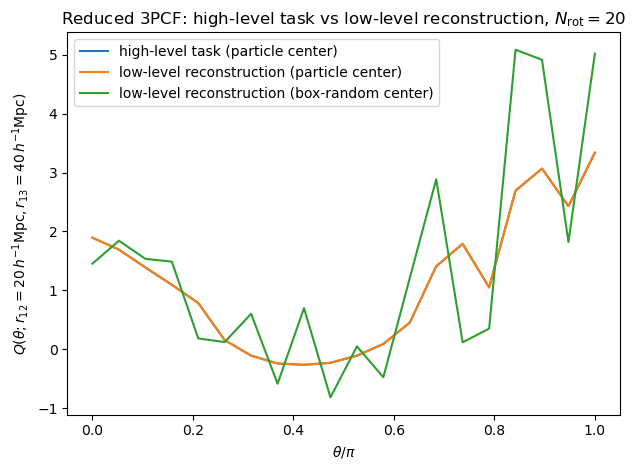

In [15]:
plt.plot(corr3pcf_pcent.theta/np.pi, corr3pcf_pcent.Q, label='high-level task (particle center)')
plt.plot(theta_values/np.pi, Q_pcenter, label='low-level reconstruction (particle center)')
plt.plot(theta_values/np.pi, Q_rcenter, label='low-level reconstruction (box-random center)')

plt.legend()
plt.title(r'Reduced 3PCF: high-level task vs low-level reconstruction, $N_{\rm rot}=20$')
plt.xlabel(r"$\theta/\pi$")
plt.ylabel(r"$Q(\theta; r_{12}=20\,h^{-1}\mathrm{Mpc}, r_{13}=40\,h^{-1}\mathrm{Mpc})$")
plt.tight_layout()
plt.show()


## 3. Standard 3PCF diagnostics

The saved high-sampling runs below test three choices that are independent of the estimator reconstruction above: a uniform-random shortcut versus an explicitly sampled random field, particle versus box-random centers, and uniform sampling in $\theta$ versus $\mu=\cos\theta$. The labels report the number of triangle rotations or sampled centers where it is useful for interpreting the residual Monte Carlo scatter.


In [16]:
# examples/scripts/run_3pcf.py & examples/configs/param_3pcf_pcenter_nrot1000.yaml
corr3pcf_pcenter_nrot1000 = Corr3PCFData(data_path="./output/quijote8000_snap004_3pcf_pcenter_nrot1000.pkl")

# examples/scripts/run_3pcf.py & examples/configs/param_3pcf_pcenter_nrot1000_mu.yaml
corr3pcf_pcenter_nrot1000_mu = Corr3PCFData(data_path="./output/quijote8000_snap004_3pcf_pcenter_nrot1000_mu.pkl")

# examples/scripts/run_3pcf_pcenter_with_random.py & examples/configs/param_3pcf_pcenter_with_random.yaml
corr3pcf_pcenter_with_random = Corr3PCFData(data_path="./output/quijote8000_snap004_3pcf_pcenter_with_random.pkl")

# examples/scripts/run_3pcf.py & examples/configs/param_3pcf_rcenter_nrot200.yaml
corr3pcf_rcenter_nrot200 = Corr3PCFData(data_path="./output/quijote8000_snap004_3pcf_rcenter_nrot200.pkl")

# examples/scripts/run_3pcf.py & examples/configs/param_3pcf_rcenter_with_random.yaml
corr3pcf_rcenter_with_random = Corr3PCFData(data_path="./output/quijote8000_snap004_3pcf_rcenter_with_random.pkl")

17:25:42 - INFO - pyhermes.io.base:Corr3PCFData - Reading 3PCF data from ---> ./output/quijote8000_snap004_3pcf_pcenter_nrot1000.pkl <---
17:25:42 - INFO - pyhermes.io.base:Corr3PCFData - theta: Num = 20, Min = 0, Max = 3.142
17:25:42 - INFO - pyhermes.io.base:Corr3PCFData - mu: Num = 20, Min = -1, Max = 1
17:25:42 - INFO - pyhermes.io.base:Corr3PCFData - Products loaded: ['rrr', 'd_delta_dd', 'r_delta_dd', 'delta_ddd', 'xi12', 'xi13', 'xi23', 'zeta', 'zeta_H', 'Q']
17:25:42 - INFO - pyhermes.io.base:Corr3PCFData - Reading 3PCF data from ---> ./output/quijote8000_snap004_3pcf_pcenter_nrot1000_mu.pkl <---
17:25:42 - INFO - pyhermes.io.base:Corr3PCFData - theta: Num = 20, Min = 0, Max = 3.142
17:25:42 - INFO - pyhermes.io.base:Corr3PCFData - mu: Num = 20, Min = -1, Max = 1
17:25:42 - INFO - pyhermes.io.base:Corr3PCFData - Products loaded: ['rrr', 'd_delta_dd', 'r_delta_dd', 'delta_ddd', 'xi12', 'xi13', 'xi23', 'zeta', 'zeta_H', 'Q']
17:25:42 - INFO - pyhermes.io.base:Corr3PCFData - Readi

### Random-field treatment and angular sampling

This comparison separates the uniform-random shortcut from an explicitly sampled random field and also checks whether the angular grid is uniform in $\theta$ or in $\mu=\cos\theta$.


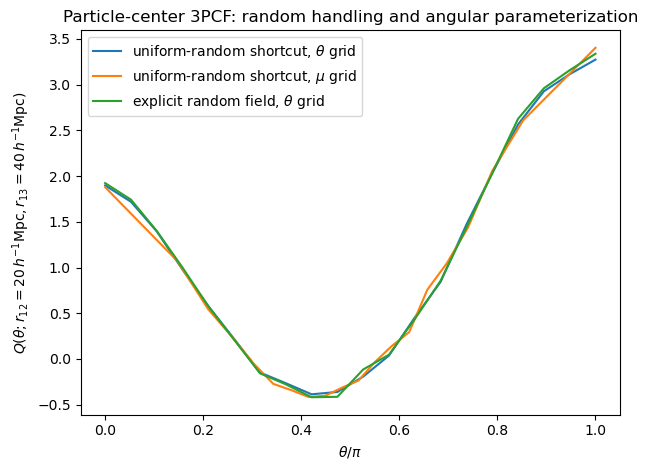

In [17]:
plt.plot(corr3pcf_pcenter_nrot1000.theta/np.pi, corr3pcf_pcenter_nrot1000.Q, label=r'uniform-random shortcut, $\theta$ grid')
plt.plot(corr3pcf_pcenter_nrot1000_mu.theta/np.pi, corr3pcf_pcenter_nrot1000_mu.Q, label=r'uniform-random shortcut, $\mu$ grid')
plt.plot(corr3pcf_pcenter_with_random.theta/np.pi, corr3pcf_pcenter_with_random.Q, label=r'explicit random field, $\theta$ grid')

plt.legend()
plt.title(r'Particle-center 3PCF: random handling and angular parameterization')
plt.xlabel(r"$\theta/\pi$")
plt.ylabel(r"$Q(\theta; r_{12}=20\,h^{-1}\mathrm{Mpc}, r_{13}=40\,h^{-1}\mathrm{Mpc})$")
plt.tight_layout()
plt.show()


### Center strategy

The next plot compares particle-centered and box-random-centered estimators. The additional explicit-random curve shows the residual effect of replacing the uniform shortcut with a sampled random field.


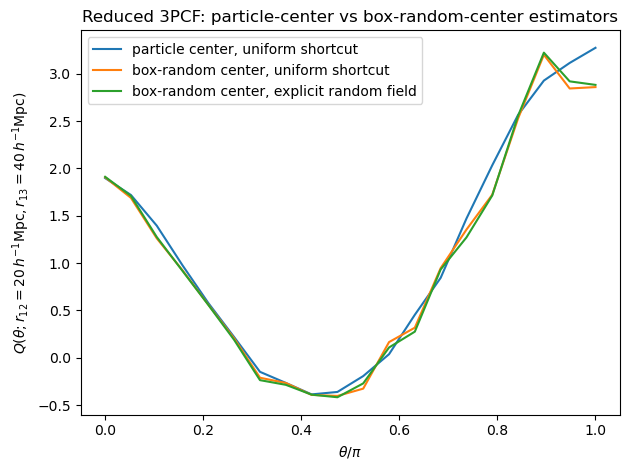

In [18]:
plt.plot(corr3pcf_pcenter_nrot1000.theta/np.pi, corr3pcf_pcenter_nrot1000.Q, label='particle center, uniform shortcut')
plt.plot(corr3pcf_rcenter_nrot200.theta/np.pi, corr3pcf_rcenter_nrot200.Q, label='box-random center, uniform shortcut')
plt.plot(corr3pcf_rcenter_with_random.theta/np.pi, corr3pcf_rcenter_with_random.Q, label='box-random center, explicit random field')

plt.legend()
plt.title(r'Reduced 3PCF: particle-center vs box-random-center estimators')
plt.xlabel(r"$\theta/\pi$")
plt.ylabel(r"$Q(\theta; r_{12}=20\,h^{-1}\mathrm{Mpc}, r_{13}=40\,h^{-1}\mathrm{Mpc})$")
plt.tight_layout()
plt.savefig(figs_dir / "corr3pcf_center_estimators.png", dpi=200, bbox_inches="tight")
plt.show()

### $\theta$ and $\mu$ grids

Finally, the same particle-centered estimator is displayed as a function of $\mu$ to expose the different sampling densities produced by uniform $\theta$ and uniform $\mu$ grids.


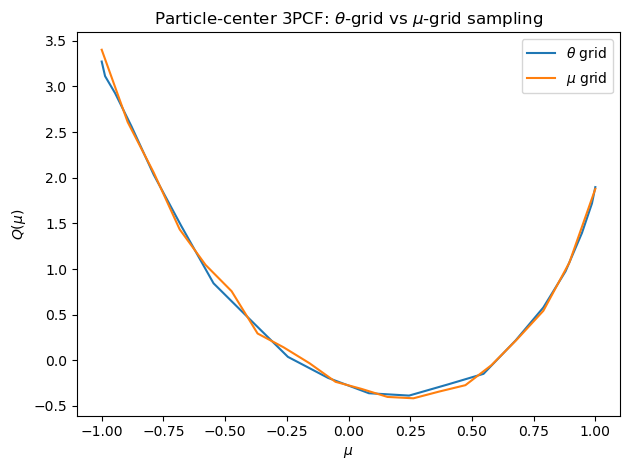

In [19]:
plt.plot(corr3pcf_pcenter_nrot1000.mu, corr3pcf_pcenter_nrot1000.Q, label=r'$\theta$ grid')
plt.plot(corr3pcf_pcenter_nrot1000_mu.mu, corr3pcf_pcenter_nrot1000_mu.Q, label=r'$\mu$ grid')

plt.xlabel(r"$\mu$")
plt.ylabel(r"$Q(\mu)$")
plt.title(r'Particle-center 3PCF: $\theta$-grid vs $\mu$-grid sampling')
plt.legend()
plt.tight_layout()
plt.show() 


## 4. 3PCF multipoles

The final section switches from direct angular curves to a multipole representation. The cells below load saved outputs to compare two field resolutions at fixed `l_max`, inspect the normalized multipole products, and verify that the multipoles reconstruct the angular 3PCF.

The saved multipole outputs used below can be produced from a config with this shape:

```yaml
Corr_3PCF_Multipole:
   sfc_field: "./output/quijote8000_snap004_sfc.pkl"
   random: "uniform"
   window:
      type: "sphere"
      len_args:
         R: 5
   binning_window12:
      type: "shell"
      len_args: {}
      other_args: {}
      mapping:
         R: "r12"
   binning_window13:
      type: "shell"
      len_args: {}
      other_args: {}
      mapping:
         R: "r13"
   sampling:
      r12: 20.0
      r13: 40.0
   l_max: 7
   execution_mode: "pair_mpi"
   products: "zeta_l"
   threads: 4
   fout_path: "./output/quijote8000_snap004_3pcf_multipole_lmax7.pkl"
```


### Compare field resolution `J` at fixed `l_max=14`

This comparison holds `l_max=14` fixed and changes only the field resolution from `J=8` to `J=9`, isolating the effect of the multiresolution representation on the recovered multipole spectrum.


17:25:43 - INFO - pyhermes.io.base:Corr3PCFMultipoleData - Reading 3PCF Multipole data from ---> ./output/quijote8000_snap004_3pcf_multipole_lmax14.pkl <---
17:25:44 - INFO - pyhermes.io.base:Corr3PCFMultipoleData - l: Num = 15, Min = 0, Max = 14
17:25:44 - INFO - pyhermes.io.base:Corr3PCFMultipoleData - Products loaded: ['rrr_l', 'delta_ddd_l', 'zeta_l', 'zeta_condition']
17:25:44 - INFO - pyhermes.io.base:Corr3PCFMultipoleData - Reading 3PCF Multipole data from ---> ./output/quijote8000_snap004_3pcf_multipole_J9_lmax14.pkl <---
17:25:44 - INFO - pyhermes.io.base:Corr3PCFMultipoleData - l: Num = 15, Min = 0, Max = 14
17:25:44 - INFO - pyhermes.io.base:Corr3PCFMultipoleData - Products loaded: ['rrr_l', 'delta_ddd_l', 'zeta_l', 'zeta_condition']


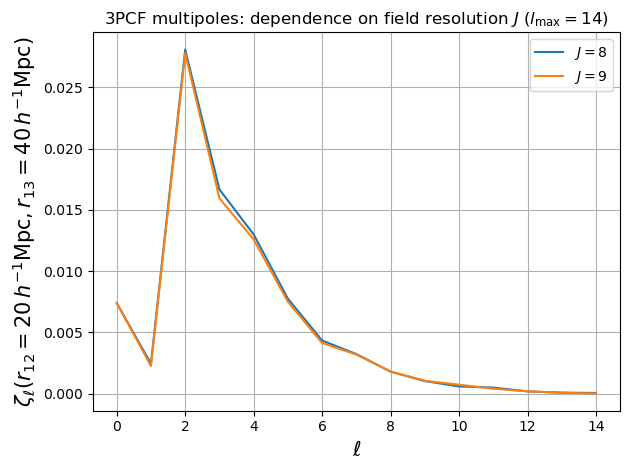

In [20]:
# examples/scripts/run_3pcf_multipole.py & examples/configs/param_3pcf_multipole_lmax14.yaml
corr3pcf_mul_j8_lmax14 = Corr3PCFMultipoleData(data_path="./output/quijote8000_snap004_3pcf_multipole_lmax14.pkl")

# examples/scripts/run_3pcf_multipole.py & examples/configs/param_3pcf_multipole_J9_lmax14.yaml
corr3pcf_mul_j9_lmax14 = Corr3PCFMultipoleData(data_path="./output/quijote8000_snap004_3pcf_multipole_J9_lmax14.pkl")

plt.plot(corr3pcf_mul_j8_lmax14.l, corr3pcf_mul_j8_lmax14.zeta_l[0], label=r'$J=8$')
plt.plot(corr3pcf_mul_j9_lmax14.l, corr3pcf_mul_j9_lmax14.zeta_l[0], label=r'$J=9$')

plt.title(r'3PCF multipoles: dependence on field resolution $J$ ($l_{\max}=14$)')
plt.xlabel(r'$\ell$', fontsize=15)
plt.ylabel(r'$\zeta_\ell(r_{12}=20\,h^{-1}\mathrm{Mpc}, r_{13}=40\,h^{-1}\mathrm{Mpc})$', fontsize=15)
plt.grid()
plt.legend()
plt.tight_layout()
plt.savefig(figs_dir / "corr3pcf_multipole_resolution.png", dpi=200, bbox_inches="tight")
plt.show()

### Inspect normalized raw multipole components

The next plot breaks the multipole output into its raw building blocks, all normalized by $\rho^3$, so it is easier to compare the relative scale of `RRR`, `DDD`, and $(\Delta D)^3$-type terms.


In [21]:
# examples/scripts/run_3pcf_multipole.py & examples/configs/param_3pcf_multipole_lmax14_with_random.yaml
corr3pcf_mul_j8_lmax14_with_random = Corr3PCFMultipoleData(data_path="./output/quijote8000_snap004_3pcf_multipole_lmax14_with_random.pkl")
l = corr3pcf_mul_j8_lmax14_with_random.l
rrr_l = corr3pcf_mul_j8_lmax14_with_random.rrr_l[0]
ddd_l = corr3pcf_mul_j8_lmax14_with_random.ddd_l[0]
delta_ddd_l = corr3pcf_mul_j8_lmax14_with_random.delta_ddd_l[0]

D = SFCField(data_path='./output/quijote8000_snap004_sfc.pkl')
rho = 1 / D.V

17:25:44 - INFO - pyhermes.io.base:Corr3PCFMultipoleData - Reading 3PCF Multipole data from ---> ./output/quijote8000_snap004_3pcf_multipole_lmax14_with_random.pkl <---
17:25:44 - INFO - pyhermes.io.base:Corr3PCFMultipoleData - l: Num = 15, Min = 0, Max = 14
17:25:44 - INFO - pyhermes.io.base:Corr3PCFMultipoleData - Products loaded: ['ddd_l', 'rrr_l', 'delta_ddd_l', 'zeta_l', 'zeta_condition']
17:25:44 - INFO - pyhermes.io.base:SFCField - Reading SFCField data from ---> ./output/quijote8000_snap004_sfc.pkl <---
17:25:44 - INFO - pyhermes.io.base:SFCField - epsilon: Shape(256, 256, 256), Min = -3.215e-06, Max = 1.343e-05, Mean = 5.96e-08, Sum = 1


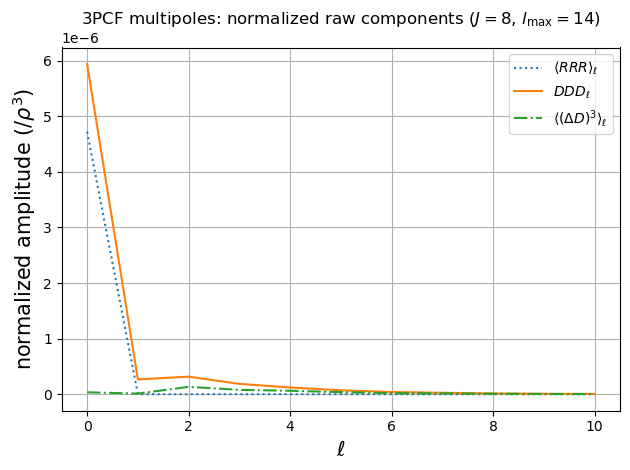

In [22]:
lmin, lmax = 0, 10
plt.plot(l[lmin:lmax+1], rrr_l[lmin:lmax+1]/rho**3, label=r'$\langle RRR \rangle_\ell$', ls=":")
plt.plot(l[lmin:lmax+1], ddd_l[lmin:lmax+1]/rho**3, label=r'$DDD_\ell$', ls="-")
plt.plot(l[lmin:lmax+1], delta_ddd_l[lmin:lmax+1]/rho**3, label=r'$\langle (\Delta D)^3 \rangle_\ell$', ls="-.")

plt.title(r'3PCF multipoles: normalized raw components ($J=8$, $l_{\max}=14$)')
plt.xlabel(r'$\ell$', fontsize=15)
plt.ylabel(r'normalized amplitude $(/\rho^3)$', fontsize=15)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()


### Consistency check: multipoles and angular 3PCF

For the uniform-random shortcut outputs used here, the computed `zeta_l` multipoles stored in the output can be read as Legendre coefficients in the expansion

$$\zeta(\theta; r_{12}, r_{13}) = \sum_{\ell=0}^{\ell_{\max}} \zeta_\ell(r_{12}, r_{13}) P_\ell(\cos\theta).$$

The primary check below therefore reconstructs the angular curve from the multipoles and overlays it with the direct standard-3PCF measurements. The particle-center curve uses `n_part = 406728` halo centers and `n_rot = 1000`; the box-random-center curve uses `n_rand = 8000000` random centers and `n_rot = 200`. The second panel projects the direct angular curves back to low-order multipoles as a diagnostic; because the saved standard 3PCF curves use a finite angular grid and finite random rotations, this projection should not be over-interpreted at high `ell`.


In [23]:
def reconstruct_zeta_from_multipoles(multipole_data, theta):
    ell = np.asarray(multipole_data.l, dtype=int)
    coeff = np.zeros(ell.max() + 1, dtype=np.float64)
    coeff[ell] = multipole_data.zeta_l[0]
    return np.polynomial.legendre.legval(np.cos(theta), coeff)

def project_zeta_to_multipoles(theta, zeta, ell_values):
    mu = np.cos(np.asarray(theta, dtype=np.float64))
    zeta = np.asarray(zeta, dtype=np.float64)
    order = np.argsort(mu)
    mu = mu[order]
    zeta = zeta[order]
    trapz = getattr(np, "trapezoid", np.trapz)

    projected = []
    for ell in np.asarray(ell_values, dtype=int):
        basis = np.zeros(ell + 1, dtype=np.float64)
        basis[ell] = 1.0
        p_ell = np.polynomial.legendre.legval(mu, basis)
        projected.append(0.5 * (2 * ell + 1) * trapz(zeta * p_ell, mu))
    return np.asarray(projected)

theta = corr3pcf_pcenter_nrot1000.theta
zeta_from_l = reconstruct_zeta_from_multipoles(corr3pcf_mul_j8_lmax14, theta)
zeta_from_l_rcenter_grid = reconstruct_zeta_from_multipoles(corr3pcf_mul_j8_lmax14, corr3pcf_rcenter_nrot200.theta)

def relative_rms(reference, comparison):
    reference = np.asarray(reference, dtype=np.float64)
    comparison = np.asarray(comparison, dtype=np.float64)
    scale = np.sqrt(np.mean(reference**2))
    return np.sqrt(np.mean((comparison - reference)**2)) / scale if scale > 0 else np.nan

print(f"relative RMS vs particle-center zeta: {relative_rms(corr3pcf_pcenter_nrot1000.zeta, zeta_from_l):.3e}")
print(f"relative RMS vs box-random-center zeta: {relative_rms(corr3pcf_rcenter_nrot200.zeta, zeta_from_l_rcenter_grid):.3e}")

relative RMS vs particle-center zeta: 3.768e-02
relative RMS vs box-random-center zeta: 7.742e-02


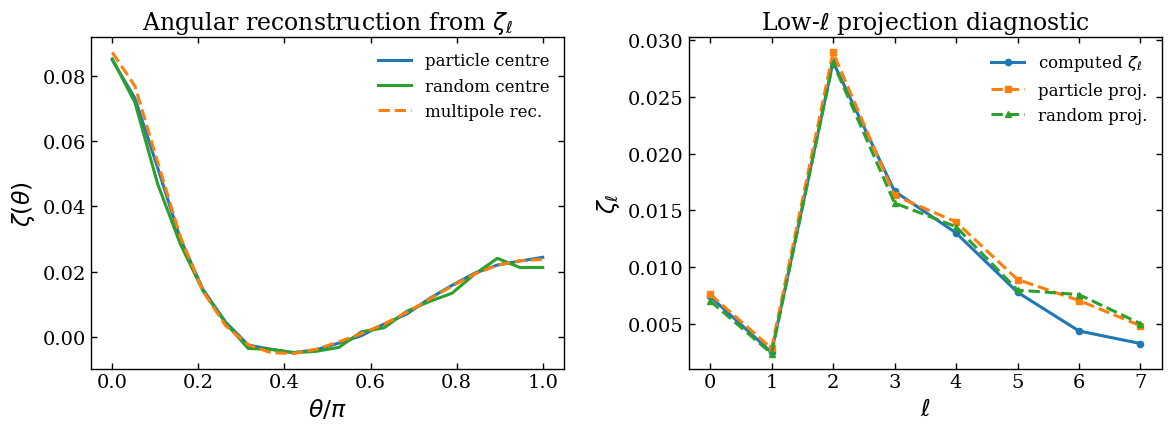

In [24]:
ell_compare = corr3pcf_mul_j8_lmax14.l[corr3pcf_mul_j8_lmax14.l <= 7]
zeta_l_projected_pcenter = project_zeta_to_multipoles(
    corr3pcf_pcenter_nrot1000.theta, corr3pcf_pcenter_nrot1000.zeta, ell_compare
)
zeta_l_projected_rcenter = project_zeta_to_multipoles(
    corr3pcf_rcenter_nrot200.theta, corr3pcf_rcenter_nrot200.zeta, ell_compare
)
zeta_l_multipole = corr3pcf_mul_j8_lmax14.zeta_l[0][np.isin(corr3pcf_mul_j8_lmax14.l, ell_compare)]

with plt.rc_context({
    "font.family": "serif",
    "font.size": 16,
    "axes.labelsize": 17,
    "axes.titlesize": 17,
    "legend.fontsize": 12,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "axes.grid": False,
}):
    fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.6))

    axes[0].plot(
        corr3pcf_pcenter_nrot1000.theta / np.pi,
        corr3pcf_pcenter_nrot1000.zeta,
        label=r"particle centre",
        color="#1f77b4",
        lw=2.2,
    )
    axes[0].plot(
        corr3pcf_rcenter_nrot200.theta / np.pi,
        corr3pcf_rcenter_nrot200.zeta,
        label=r"random centre",
        color="#2ca02c",
        lw=2.2,
    )
    axes[0].plot(
        theta / np.pi,
        zeta_from_l,
        "--",
        label=r"multipole rec.",
        color="#ff7f0e",
        lw=2.2,
    )
    axes[0].set_xlabel(r"$\theta/\pi$")
    axes[0].set_ylabel(r"$\zeta(\theta)$")
    axes[0].set_title(r"Angular reconstruction from $\zeta_\ell$")
    axes[0].legend(frameon=False)

    axes[1].plot(
        ell_compare,
        zeta_l_multipole,
        "o-",
        label=r"computed $\zeta_\ell$",
        color="#1f77b4",
        lw=2.2,
        ms=4.5,
    )
    axes[1].plot(
        ell_compare,
        zeta_l_projected_pcenter,
        "s--",
        label=r"particle proj.",
        color="#ff7f0e",
        lw=2.2,
        ms=4.5,
    )
    axes[1].plot(
        ell_compare,
        zeta_l_projected_rcenter,
        "^--",
        label=r"random proj.",
        color="#2ca02c",
        lw=2.2,
        ms=4.5,
    )
    axes[1].set_xlabel(r"$\ell$")
    axes[1].set_ylabel(r"$\zeta_\ell$")
    axes[1].set_title(r"Low-$\ell$ projection diagnostic")
    axes[1].legend(frameon=False)

    for ax in axes:
        ax.grid(False)
        ax.tick_params(direction="in", top=True, right=True, width=1.0, length=4)
        for spine in ax.spines.values():
            spine.set_linewidth(1.0)

    fig.tight_layout(w_pad=1.4)
    plt.savefig(figs_dir / "corr3pcf_multipole_standard_consistency.png", dpi=240, bbox_inches="tight")
    plt.show()
